# Fuzzy (Mamdani) - Driver-Error Execution Telemetry (raw analysis)
### SEM Hydrogen Urban Concept - two-motor powertrain + **SZFC-1000** fuel cell

This notebook analyses the **realistic driver-execution telemetry** for the Fuzzy strategy:
the Fuzzy plan (found by a **Mamdani fuzzy** rule-based controller) driven through the exact `simulate()` physics but with
**realistic, bounded human execution errors** applied (speed-tracking, throttle modulation, glide/brake/
acceleration timing, corner-entry, stop-&-go and steering-line jitter, driver fatigue per lap, and a
0.5 s two-motor servo switch penalty). The strategy itself is unchanged -- only the *execution* is imperfect.

The telemetry is generated by `margin/driver_sim.py` and saved to
`margin/Fuzzy/fuzzy_driver_error_telemetry.csv` (identical schema to the baseline). Here it is loaded
and put through the **same** analysis and charts as the baseline `fuzzy_analyze` notebook, so you can read the
**raw result** of the imperfect run: *where the car actually gassed vs glided, which motor was working, and the
resulting speed, hydrogen burn and Art. 54e efficiency* -- with no baseline comparison.


In [1]:
import os, sys
# run from the repo root so `from digital_twin import ...` and data/ paths resolve
root = os.getcwd()
while root != os.path.dirname(root) and not os.path.isdir(os.path.join(root, 'digital_twin')):
    root = os.path.dirname(root)
os.chdir(root); sys.path.insert(0, root)

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap, BoundaryNorm, TwoSlopeNorm
from IPython.display import display
%matplotlib inline

from digital_twin import config, strategy_analysis as sa, powertrain as pt

plt.rcParams.update({
    'figure.dpi': 120, 'savefig.dpi': 120, 'savefig.bbox': 'tight',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#ececea', 'grid.linewidth': 0.8,
    'axes.edgecolor': '#9a9a95', 'font.size': 11.5,
    'axes.titlesize': 14, 'axes.titleweight': 'bold', 'axes.titlepad': 12,
    'axes.labelsize': 12, 'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'xtick.color': '#3a3a38', 'ytick.color': '#3a3a38', 'legend.fontsize': 10,
})

motors = pt.load_motors()
accel_motor = motors[config.ACCEL_MOTOR_NAME]
cruise_motor = motors[config.CRUISE_MOTOR_NAME]
fc = pt.load_fuel_cells()[config.DEFAULT_FC_NAME]
print('Accel motor:', accel_motor.name, '(peak', round(accel_motor.max_mech_power_w()), 'W)')
print('Cruise mtr :', cruise_motor.name, '(peak', round(cruise_motor.max_mech_power_w()), 'W)')
print('Fuel cell  :', fc.name, '(rated', fc.rated_power_w, 'W) <-- new SZFC-1000')


powertrain.load_motors(): excluding ['Mitsubishi M2096D-III'] -- exceeds 60.0V vehicle electrical limit (technical-inspection risk)
Accel motor: BLDC 650W (peak 953 W)
Cruise mtr : BG 42x30 dCore (peak 156 W)
Fuel cell  : SZFC-1000 (rated 1000 W) <-- new SZFC-1000


## 1 - Load the driver-error telemetry
Read the realistic-execution telemetry produced by `margin/driver_sim.py`, enrich it with the driver-facing
columns, and print the whole-attempt summary.


In [2]:
TITLE = 'Fuzzy'
SRC_CSV = 'margin/Fuzzy/fuzzy_driver_error_telemetry.csv'   # realistic driver-execution telemetry (margin/driver_sim.py)
OUT_CSV = os.path.join('margin', 'Fuzzy', 'fuzzy_error_attempt_analysis.csv')
tel = pd.read_csv(SRC_CSV)
df = sa.enrich(tel)
df.to_csv(OUT_CSV, index=False)
S = sa.summary(tel, TITLE)
print('=== ' + TITLE + ' DRIVER-ERROR TELEMETRY -- whole attempt (two-motor + SZFC-1000, realistic execution) ===')
for k, v in S.items():
    print(f'{k:18}: {v}')


=== Fuzzy DRIVER-ERROR TELEMETRY -- whole attempt (two-motor + SZFC-1000, realistic execution) ===
strategy          : Fuzzy
distance_km       : 14.505
time_min          : 34.24
avg_speed_kmh     : 25.42
h2_litres         : 70.32
score_km_per_m3   : 191.1
gas_pct           : 65.2
glide_pct         : 34.4
brake_pct         : 0.5
accel_motor_pct   : 3.3
cruise_motor_pct  : 96.7
time_ok           : True
rule_violations   : 0


In [3]:
# shared colours + a stop/start marker helper for every track map
ymax = df.v_kmh.max() * 1.05
PHASE_COLORS = sa.PHASE_COLORS          # gas=green, glide=amber, brake=red
MOTOR_COLORS = sa.MOTOR_COLORS
PHASE_LABEL = {'gas': 'GAS - motor ON (accelerating)',
               'glide': 'GLIDE - motor OFF (coasting)', 'brake': 'BRAKE'}
MOTOR_LABEL = {accel_motor.name: accel_motor.name + '  -  acceleration motor',
               cruise_motor.name: cruise_motor.name + '  -  cruise motor'}
ev = sa.event_xy(df)

def mark_stops(ax, annotate=True):
    sfx, sfy = ev['start_finish']; s1 = ev['stop-and-go 1']; s2 = ev['stop-and-go 2']
    ax.scatter(*s2, s=430, marker='*', facecolor='#111111', edgecolor='white', lw=1.4, zorder=9)
    ax.scatter(sfx, sfy, s=360, marker='s', facecolor='#0d47a1', edgecolor='white', lw=1.6, zorder=10)
    ax.scatter(s1[0], s1[1] + 90, s=430, marker='*', facecolor='#6a3d9a', edgecolor='white', lw=1.4, zorder=11)
    ax.plot([sfx, s1[0]], [sfy, s1[1] + 90], color='#6a3d9a', lw=1.0, ls=':', zorder=8)
    if annotate:
        ax.annotate('START / FINISH', (sfx, sfy), textcoords='offset points', xytext=(12, -14),
                    fontsize=9.5, fontweight='bold', color='#0d47a1')
        ax.annotate('STOP-AND-GO 1', (s1[0], s1[1] + 90), textcoords='offset points', xytext=(12, 4),
                    fontsize=9.5, fontweight='bold', color='#6a3d9a')
        ax.annotate('STOP-AND-GO 2', s2, textcoords='offset points', xytext=(12, 3),
                    fontsize=9.5, fontweight='bold', color='#111111')

STOP_HANDLES = [
    Line2D([0], [0], marker='s', color='none', markerfacecolor='#0d47a1', markeredgecolor='white', markersize=13, label='start / finish'),
    Line2D([0], [0], marker='*', color='none', markerfacecolor='#6a3d9a', markeredgecolor='white', markersize=15, label='stop-and-go 1'),
    Line2D([0], [0], marker='*', color='none', markerfacecolor='#111111', markeredgecolor='white', markersize=15, label='stop-and-go 2'),
]

# one representative lap (lap 2 -- has both stop-and-gos) for the detailed views
steady = df[df.lap == 2].copy()
sg2_lapkm = steady.loc[steady.stop_label == 'stop-and-go 2', 'lap_distance_km']
sg2_lapkm = float(sg2_lapkm.iloc[0]) if len(sg2_lapkm) else None
print('steady lap =', 2, '|', len(steady), 'points | phases:', steady.drive_phase.value_counts().to_dict())


steady lap = 2 | 734 points | phases: {'gas': 468, 'glide': 262, 'brake': 4}


## 2 - Whole-attempt speed overview
All four laps end to end, with the compulsory stop-and-gos marked.

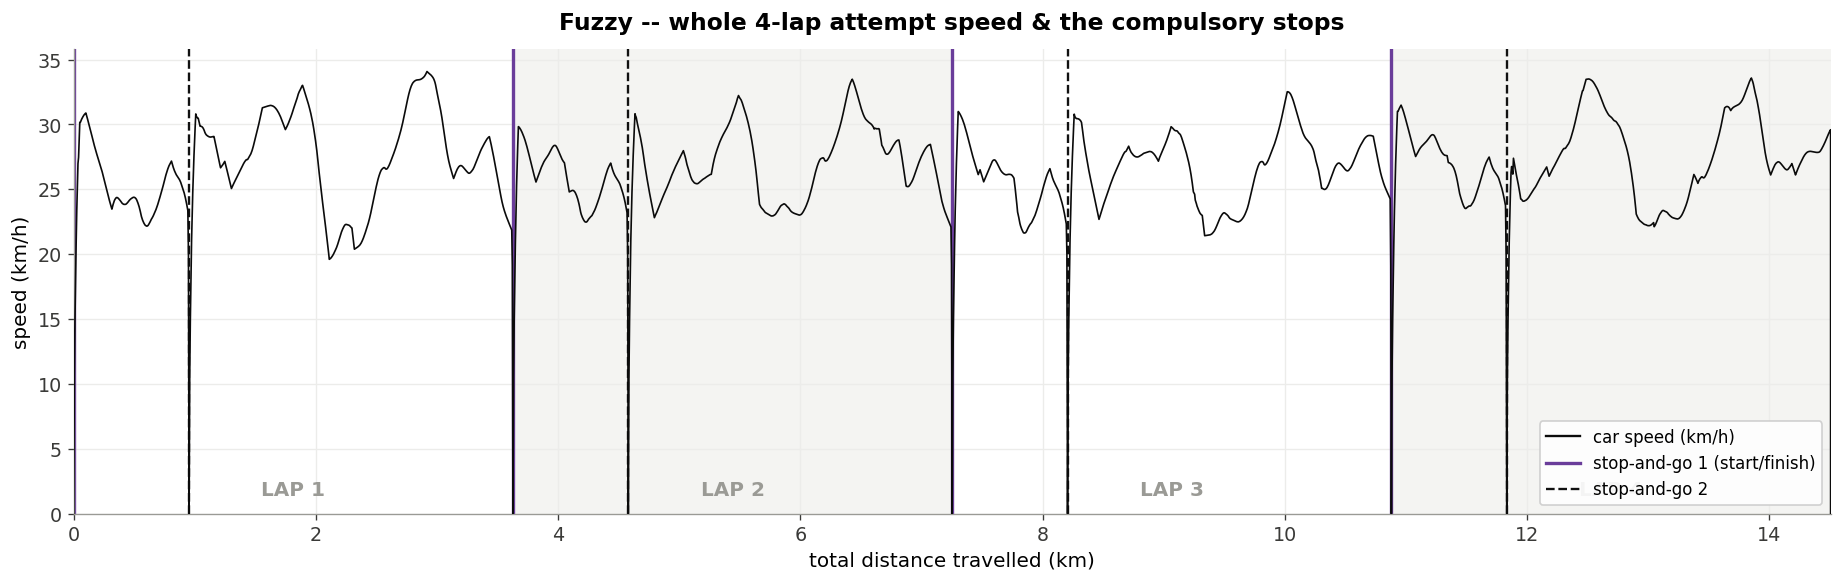

In [4]:
fig, ax = plt.subplots(figsize=(15.5, 5))
for lap in sorted(df.lap.unique()):
    seg = df[df.lap == lap]
    if lap % 2 == 0:
        ax.axvspan(seg.distance_km.min(), seg.distance_km.max(), color='#f4f4f2', zorder=0)
    ax.text((seg.distance_km.min() + seg.distance_km.max()) / 2, ymax * 0.04, 'LAP ' + str(lap),
            ha='center', fontsize=12, fontweight='bold', color='#9a9a95')
ax.plot(df.distance_km, df.v_kmh, color='#0b0b0b', lw=1.0, zorder=3)
for _, r in df[df.stop_label == 'stop-and-go 1'].iterrows():
    ax.axvline(r.distance_km, color='#6a3d9a', lw=2.0)
for _, r in df[df.stop_label == 'stop-and-go 2'].iterrows():
    ax.axvline(r.distance_km, color='#111111', ls='--', lw=1.4)
ax.set_xlim(0, df.distance_km.max()); ax.set_ylim(0, ymax)
ax.set_xlabel('total distance travelled (km)'); ax.set_ylabel('speed (km/h)')
ax.set_title(TITLE + ' -- whole 4-lap attempt speed & the compulsory stops')
ax.legend(handles=[Line2D([0], [0], color='#0b0b0b', lw=1.4, label='car speed (km/h)'),
                   Line2D([0], [0], color='#6a3d9a', lw=2.0, label='stop-and-go 1 (start/finish)'),
                   Line2D([0], [0], color='#111111', ls='--', lw=1.4, label='stop-and-go 2')],
          loc='lower right', framealpha=0.9)
plt.tight_layout(); plt.show()


## Track maps - which motor & how fast (steady lap)
Geo-accurate maps of the Lusail lap. Left: which motor drives each part. Right: speed heatmap.

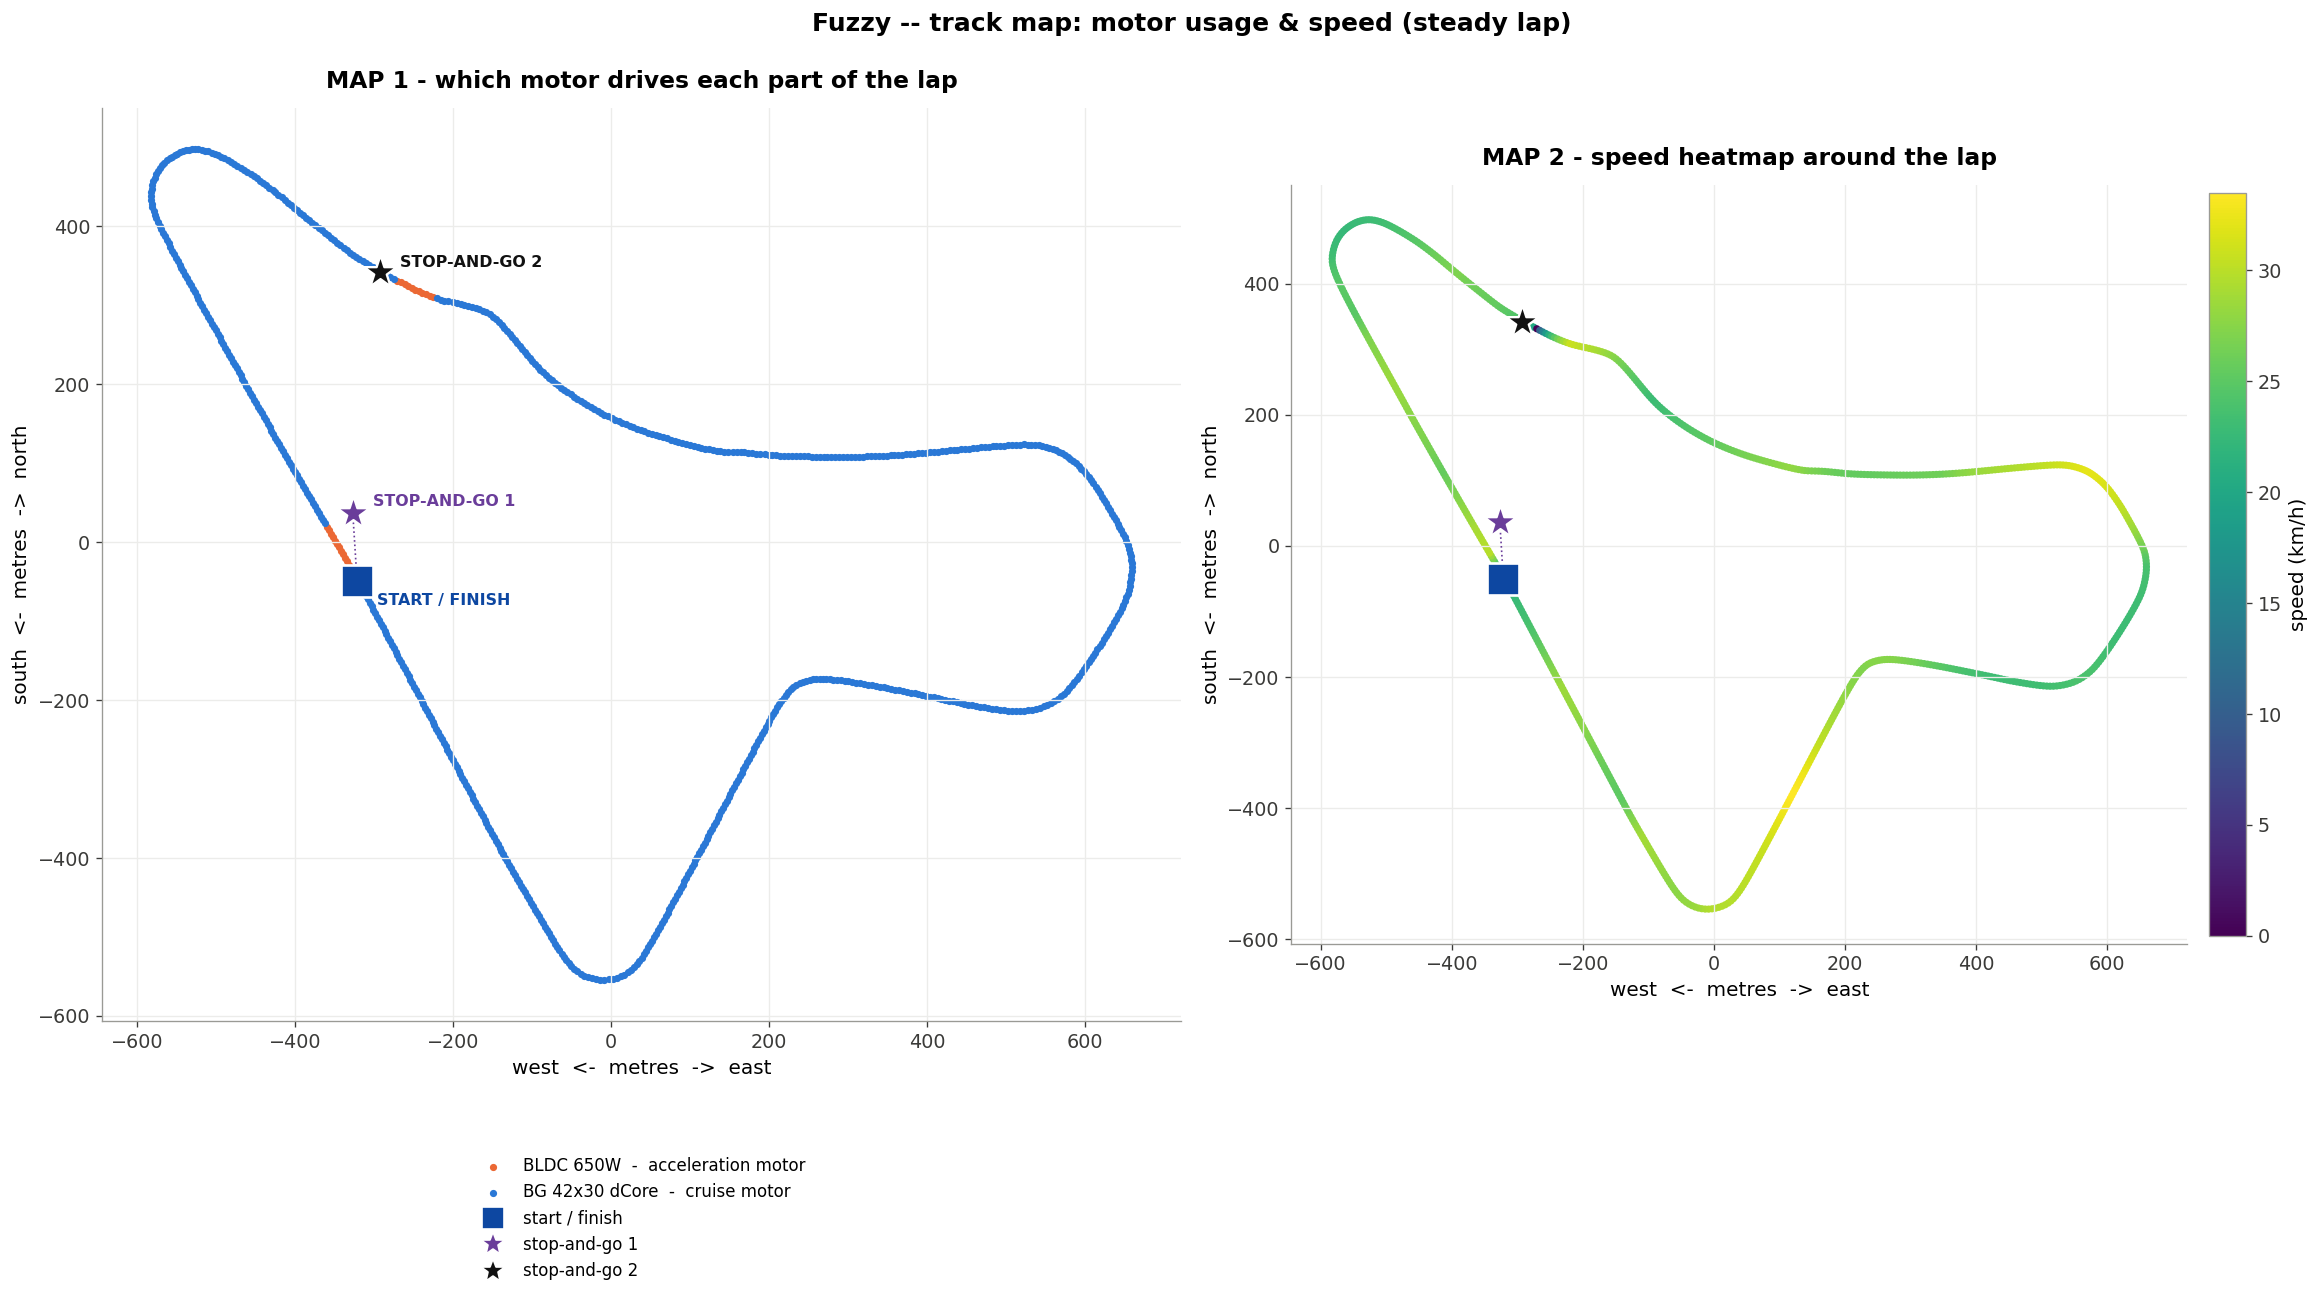

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9.5))  # larger, true geometry (equal aspect)
for name, c in MOTOR_COLORS.items():
    m = steady.active_motor == name
    ax1.scatter(steady.x_m[m], steady.y_m[m], s=11, c=c, label=MOTOR_LABEL.get(name, name))
mark_stops(ax1)
ax1.set_aspect('equal'); ax1.set_title('MAP 1 - which motor drives each part of the lap')
ax1.set_xlabel('west  <-  metres  ->  east'); ax1.set_ylabel('south  <-  metres  ->  north')
h, l = ax1.get_legend_handles_labels()
ax1.legend(h + STOP_HANDLES, l + [x.get_label() for x in STOP_HANDLES],
           loc='lower center', bbox_to_anchor=(0.5, -0.30), frameon=False)

sc = ax2.scatter(steady.x_m, steady.y_m, s=11, c=steady.v_kmh, cmap='viridis')
mark_stops(ax2, annotate=False)
ax2.set_aspect('equal'); ax2.set_title('MAP 2 - speed heatmap around the lap')
ax2.set_xlabel('west  <-  metres  ->  east'); ax2.set_ylabel('south  <-  metres  ->  north')
cb = fig.colorbar(sc, ax=ax2, shrink=0.8, pad=0.02); cb.set_label('speed (km/h)')
fig.suptitle(TITLE + ' -- track map: motor usage & speed (steady lap)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()


## Track map - where to GAS vs GLIDE
Green = motor powering; amber = coasting motor-off; red = braking.

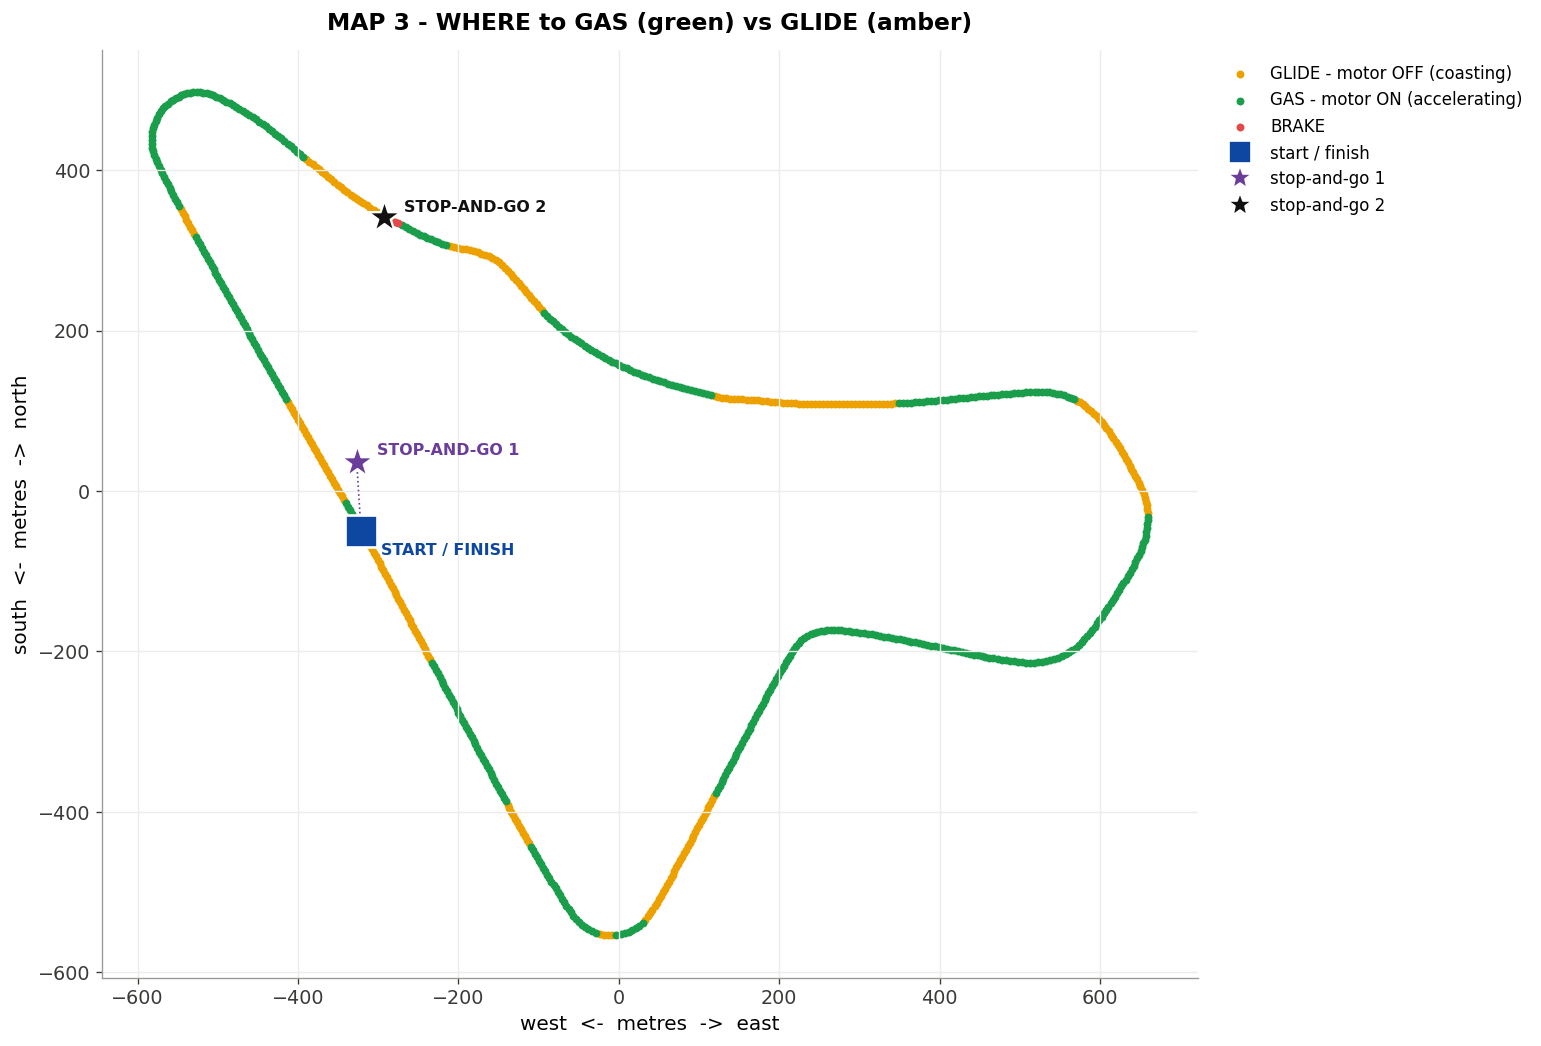

In [6]:
fig, ax = plt.subplots(figsize=(13, 11.5))  # larger, true geometry (equal aspect)
for ph in ['glide', 'gas', 'brake']:
    m = steady.drive_phase == ph
    if m.any():
        ax.scatter(steady.x_m[m], steady.y_m[m], s=14, c=PHASE_COLORS[ph], label=PHASE_LABEL[ph])
mark_stops(ax)
ax.set_aspect('equal')
ax.set_title('MAP 3 - WHERE to GAS (green) vs GLIDE (amber)')
ax.set_xlabel('west  <-  metres  ->  east'); ax.set_ylabel('south  <-  metres  ->  north')
h, l = ax.get_legend_handles_labels()
ax.legend(h + STOP_HANDLES, l + [x.get_label() for x in STOP_HANDLES],
          loc='upper left', bbox_to_anchor=(1.01, 1.0), frameon=False)
plt.tight_layout(); plt.show()


## The driver heatmap - the whole lap at a glance
One stacked strip per channel, sharing the lap-distance axis: **speed, the gas/glide command, which motor, road grade, and hydrogen burn**. This is the single view a driver (or the strategy engineer) reads off during the run.

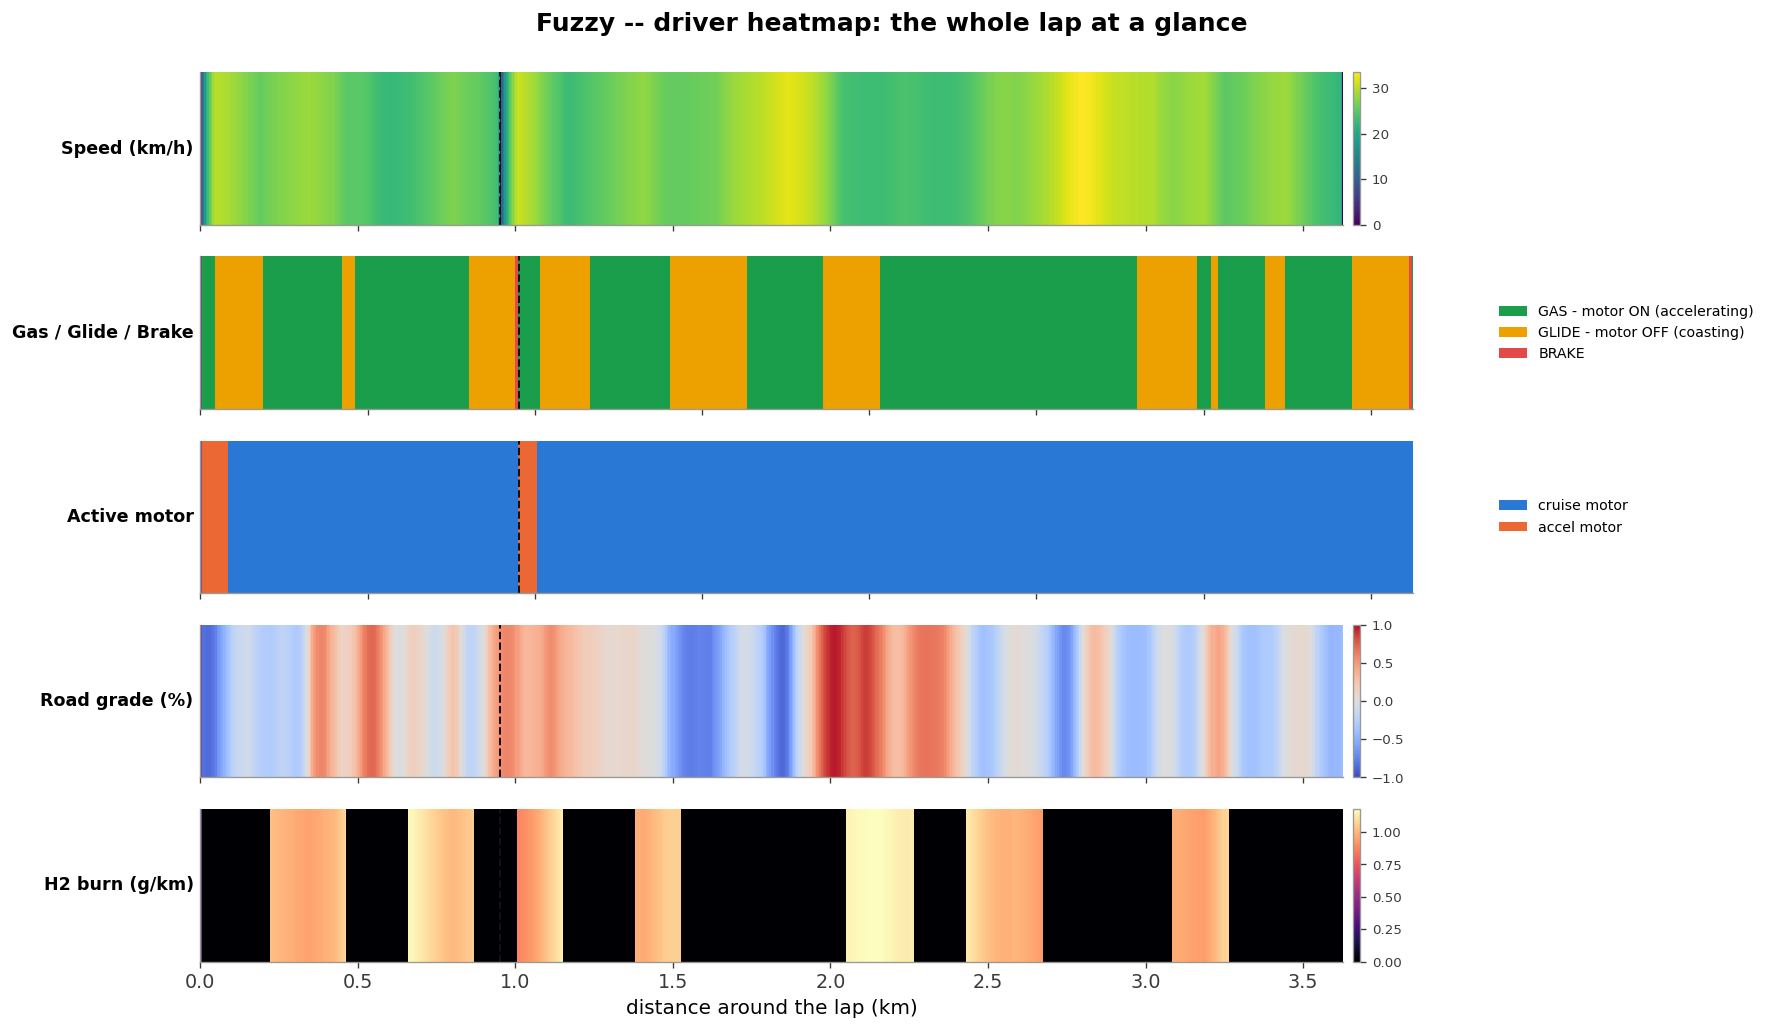

In [7]:
# ============ THE DRIVER HEATMAP =============================================
# One strip per channel, all sharing the lap-distance axis: everything the driver
# needs at a glance -- speed, the gas/glide command, which motor, the road grade,
# and the resulting hydrogen burn. Colour = value along the track.
s = steady.sort_values('lap_distance_km')
x = s.lap_distance_km.to_numpy()
xe = np.concatenate([[x[0]], (x[:-1] + x[1:]) / 2, [x[-1]]])   # cell edges

fc_flow_g_km = s.h2_flow_m3_s.to_numpy() * 1000.0 * config.H2_DENSITY_G_PER_L_STP * 3600.0 / np.clip(s.v_kmh.to_numpy(), 1, None)
motor_num = (s.active_motor == accel_motor.name).astype(int).to_numpy()   # 1 = accel motor, 0 = cruise

channels = [
    ('Speed (km/h)',        s.v_kmh.to_numpy(),   'viridis', None,  'continuous'),
    ('Gas / Glide / Brake', s.gas_glide_num.to_numpy(), 'phase', None, 'phase'),
    ('Active motor',        motor_num,            'motor', None,     'motor'),
    ('Road grade (%)',      s.grade_pct.to_numpy(), 'coolwarm', 'diverging', 'continuous'),
    ('H2 burn (g/km)',      fc_flow_g_km,         'magma',   None,   'continuous'),
]
phase_cmap = ListedColormap([PHASE_COLORS['glide'], PHASE_COLORS['gas'], PHASE_COLORS['brake']])
motor_cmap = ListedColormap([MOTOR_COLORS[cruise_motor.name], MOTOR_COLORS[accel_motor.name]])

fig, axes = plt.subplots(len(channels), 1, figsize=(15, 8.6), sharex=True)
for ax, (label, vals, cmap, kind, mode) in zip(axes, channels):
    v = vals.reshape(1, -1)
    if mode == 'phase':
        mesh = ax.pcolormesh(xe, [0, 1], v, cmap=phase_cmap, norm=BoundaryNorm([-0.5, 0.5, 1.5, 2.5], 3))
    elif mode == 'motor':
        mesh = ax.pcolormesh(xe, [0, 1], v, cmap=motor_cmap, norm=BoundaryNorm([-0.5, 0.5, 1.5], 2))
    elif kind == 'diverging':
        mx = max(1.0, np.abs(vals).max())
        mesh = ax.pcolormesh(xe, [0, 1], v, cmap=cmap, norm=TwoSlopeNorm(0.0, -mx, mx))
    else:
        mesh = ax.pcolormesh(xe, [0, 1], v, cmap=cmap)
    ax.set_yticks([]); ax.set_ylabel(label, rotation=0, ha='right', va='center', fontsize=10.5, fontweight='bold')
    ax.grid(False)
    if mode not in ('phase', 'motor'):
        cb = fig.colorbar(mesh, ax=ax, pad=0.008, fraction=0.05); cb.ax.tick_params(labelsize=8)
    if sg2_lapkm is not None:
        ax.axvline(sg2_lapkm, color='#111111', ls='--', lw=1.2)
    ax.axvline(0, color='#6a3d9a', lw=1.6)
axes[-1].set_xlabel('distance around the lap (km)')
# legends for the two categorical strips
axes[1].legend(handles=[Patch(facecolor=PHASE_COLORS[p], label=PHASE_LABEL[p]) for p in ['gas', 'glide', 'brake']],
               loc='center left', bbox_to_anchor=(1.06, 0.5), frameon=False, fontsize=8.5)
axes[2].legend(handles=[Patch(facecolor=MOTOR_COLORS[cruise_motor.name], label='cruise motor'),
                        Patch(facecolor=MOTOR_COLORS[accel_motor.name], label='accel motor')],
               loc='center left', bbox_to_anchor=(1.06, 0.5), frameon=False, fontsize=8.5)
fig.suptitle(TITLE + ' -- driver heatmap: the whole lap at a glance', fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout(); plt.show()


## Speed heatmap - every lap
Confirms the strategy repeats lap to lap (lap 1 has no stop-and-go 1 at the standing start).

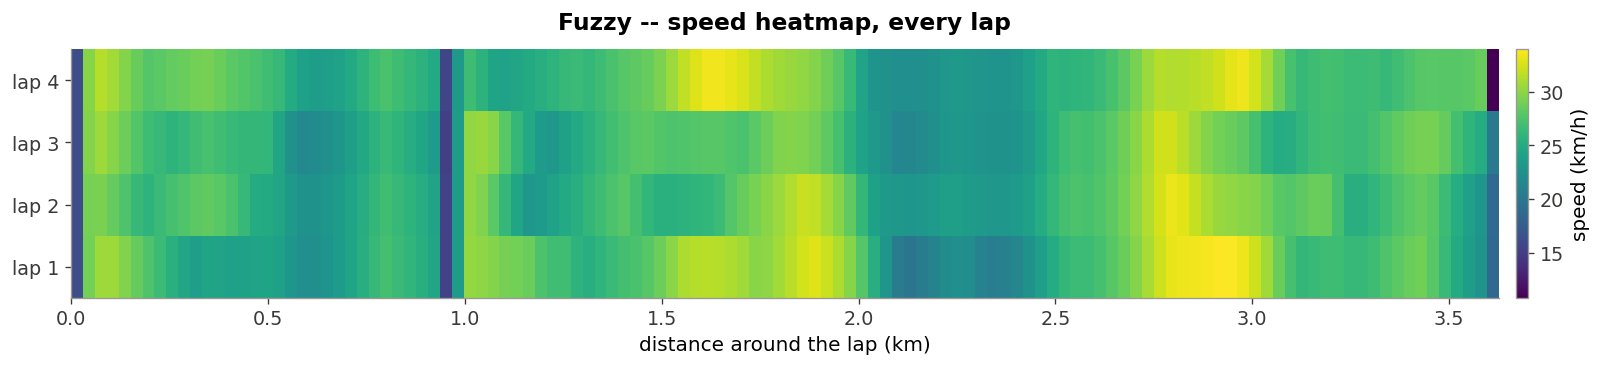

In [8]:
# 2-D heatmap: speed over (lap x distance-around-lap) -- shows the strategy is
# repeatable lap to lap (lap 1 differs: no stop-and-go 1 at the standing start).
nb = 120
bins = np.linspace(0, df.lap_distance_km.max(), nb + 1)
mid = 0.5 * (bins[:-1] + bins[1:])
laps = sorted(df.lap.unique())
grid_speed = np.full((len(laps), nb), np.nan)
for r, lap in enumerate(laps):
    d = df[df.lap == lap]
    idx = np.clip(np.digitize(d.lap_distance_km, bins) - 1, 0, nb - 1)
    for b in range(nb):
        sel = idx == b
        if sel.any():
            grid_speed[r, b] = d.v_kmh.to_numpy()[sel].mean()
fig, ax = plt.subplots(figsize=(15, 3.2))
im = ax.pcolormesh(bins, np.arange(len(laps) + 1), grid_speed, cmap='viridis')
ax.set_yticks(np.arange(len(laps)) + 0.5); ax.set_yticklabels(['lap ' + str(l) for l in laps])
ax.set_xlabel('distance around the lap (km)'); ax.set_title(TITLE + ' -- speed heatmap, every lap')
ax.grid(False)
cb = fig.colorbar(im, ax=ax, pad=0.01); cb.set_label('speed (km/h)')
plt.tight_layout(); plt.show()


## Elevation, slope & where the accel motor works

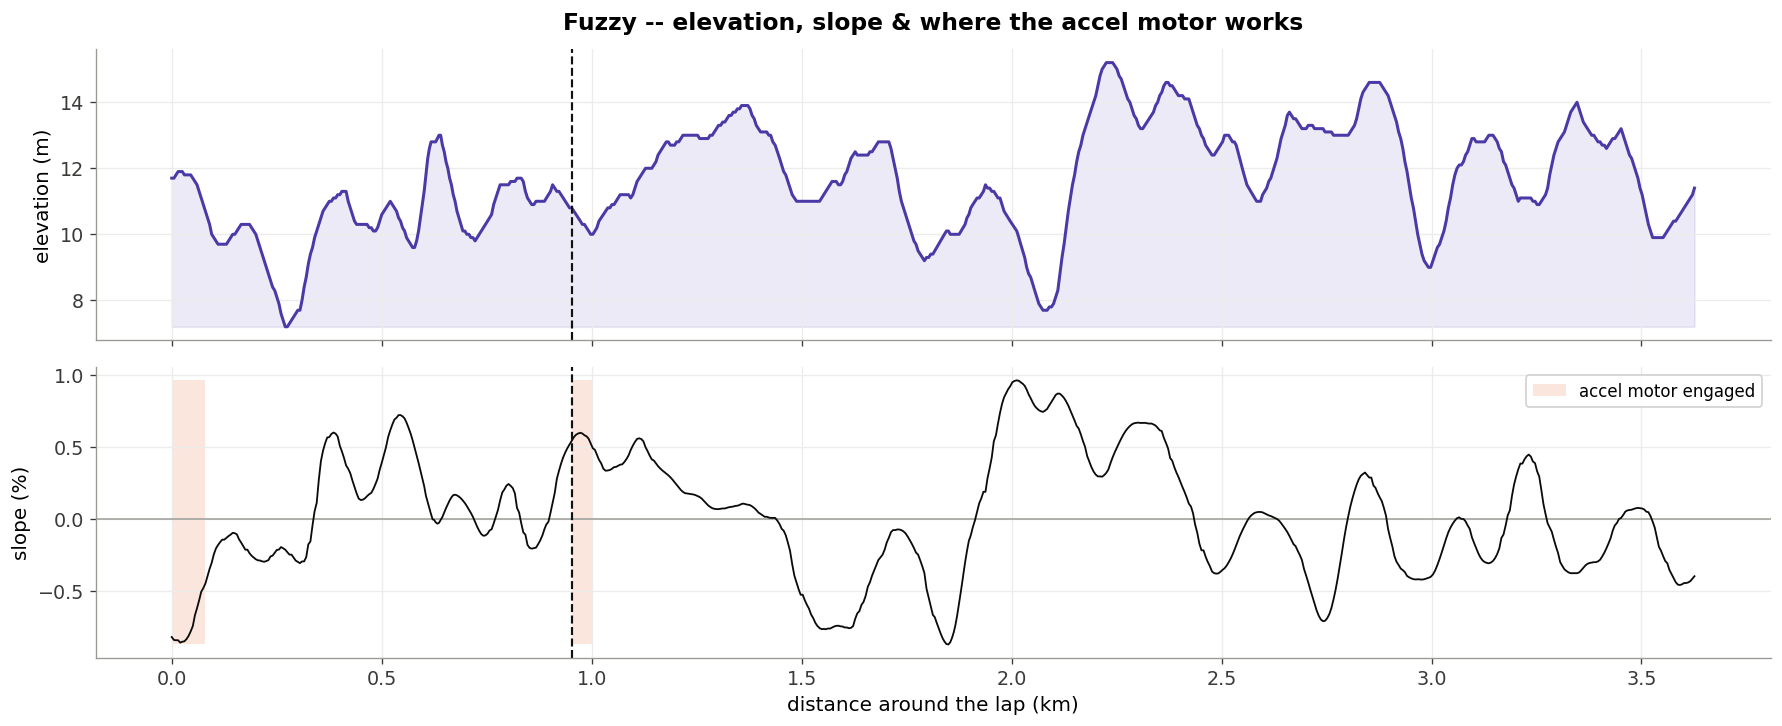

In [9]:
fig, (axa, axb) = plt.subplots(2, 1, figsize=(15, 6.2), sharex=True)
axa.plot(steady.lap_distance_km, steady.altitude_m, color='#4a3aa7', lw=1.8)
axa.fill_between(steady.lap_distance_km, steady.altitude_m.min(), steady.altitude_m, color='#4a3aa7', alpha=0.10)
axa.set_ylabel('elevation (m)'); axa.set_title(TITLE + ' -- elevation, slope & where the accel motor works')
axb.axhline(0, color='#9a9a95', lw=0.9)
axb.plot(steady.lap_distance_km, steady.grade_pct, color='#0b0b0b', lw=1.1)
mask = (steady.active_motor == accel_motor.name).to_numpy()
axb.fill_between(steady.lap_distance_km, steady.grade_pct.min(), steady.grade_pct.max(),
                 where=mask, color='#eb6834', alpha=0.16, lw=0, label='accel motor engaged')
axb.set_ylabel('slope (%)'); axb.set_xlabel('distance around the lap (km)')
axb.legend(loc='upper right', framealpha=0.9)
if sg2_lapkm is not None:
    for ax in (axa, axb):
        ax.axvline(sg2_lapkm, color='#111111', ls='--', lw=1.3)
plt.tight_layout(); plt.show()


## Strategy zones - the lap divided up
The lap split into contiguous zones by dominant action (gas/glide) and motor - a plain cheat-sheet of the lap.

Lap divided into 12 strategy zones:


,from_km,to_km,action,motor,avg_kmh
0,-0.0,-0.0,GAS,accel,0.0
1,0.0,0.2,GLIDE,accel,26.6
2,0.2,0.8,GAS,cruise,25.5
3,0.8,1.2,GLIDE,cruise,25.2
4,1.2,1.4,GAS,cruise,25.2
5,1.4,1.6,GLIDE,cruise,26.4
6,1.6,1.8,GAS,cruise,28.9
7,1.8,2.1,GLIDE,cruise,28.4
8,2.1,2.8,GAS,cruise,26.5
9,2.8,3.0,GLIDE,cruise,30.5


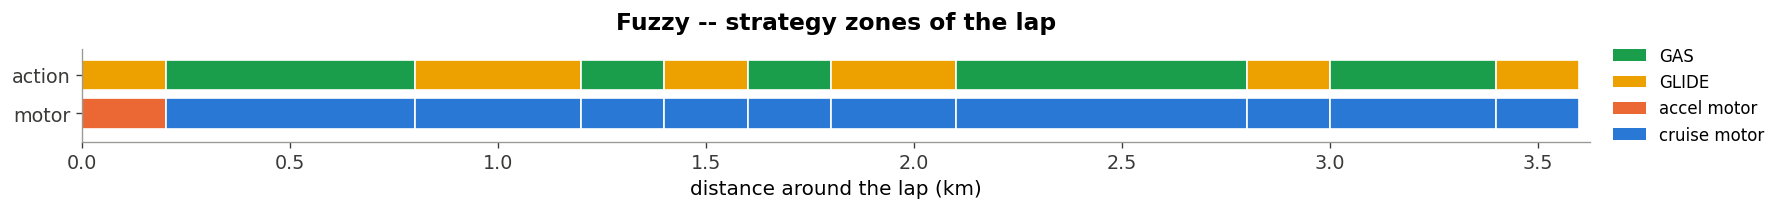

In [10]:
# Divide ONE lap into contiguous strategy zones: dominant action (gas/glide) and
# which motor, per ~150 m block -- a plain driver cheat-sheet of the lap.
block_m = 150.0
s = steady.sort_values('lap_distance_km').reset_index(drop=True)
blk = (s.lap_distance_km * 1000 // block_m).astype(int)
rows = []
for b, g in s.groupby(blk):
    ph = g.drive_phase.mode().iloc[0]
    mot = g.active_motor.mode().iloc[0]
    rows.append({'from_km': round(g.lap_distance_km.min(), 2), 'to_km': round(g.lap_distance_km.max(), 2),
                 'action': ph.upper(), 'motor': 'accel' if mot == accel_motor.name else 'cruise',
                 'avg_kmh': round(g.v_kmh.mean(), 1), 'avg_grade': round(g.grade_pct.mean(), 1)})
zones = pd.DataFrame(rows)
# merge consecutive blocks with the same (action, motor) into zones
zones['grp'] = ((zones.action != zones.action.shift()) | (zones.motor != zones.motor.shift())).cumsum()
merged = zones.groupby('grp').agg(from_km=('from_km', 'min'), to_km=('to_km', 'max'),
                                  action=('action', 'first'), motor=('motor', 'first'),
                                  avg_kmh=('avg_kmh', 'mean')).round(1).reset_index(drop=True)
print('Lap divided into', len(merged), 'strategy zones:')
display(merged)

fig, ax = plt.subplots(figsize=(15, 1.9))
for _, z in merged.iterrows():
    ax.barh(0, z.to_km - z.from_km, left=z.from_km, height=0.6,
            color=PHASE_COLORS['gas'] if z.action == 'GAS' else PHASE_COLORS['glide'],
            edgecolor='white')
    ax.barh(-0.75, z.to_km - z.from_km, left=z.from_km, height=0.6,
            color=MOTOR_COLORS[accel_motor.name] if z.motor == 'accel' else MOTOR_COLORS[cruise_motor.name],
            edgecolor='white')
ax.set_yticks([0, -0.75]); ax.set_yticklabels(['action', 'motor'])
ax.set_ylim(-1.3, 0.5); ax.set_xlim(0, steady.lap_distance_km.max()); ax.grid(False)
ax.set_xlabel('distance around the lap (km)'); ax.set_title(TITLE + ' -- strategy zones of the lap')
ax.legend(handles=[Patch(facecolor=PHASE_COLORS['gas'], label='GAS'), Patch(facecolor=PHASE_COLORS['glide'], label='GLIDE'),
                   Patch(facecolor=MOTOR_COLORS[accel_motor.name], label='accel motor'),
                   Patch(facecolor=MOTOR_COLORS[cruise_motor.name], label='cruise motor')],
          loc='center left', bbox_to_anchor=(1.005, 0.5), frameon=False)
plt.tight_layout(); plt.show()


## Whole-attempt efficiency - the headline result

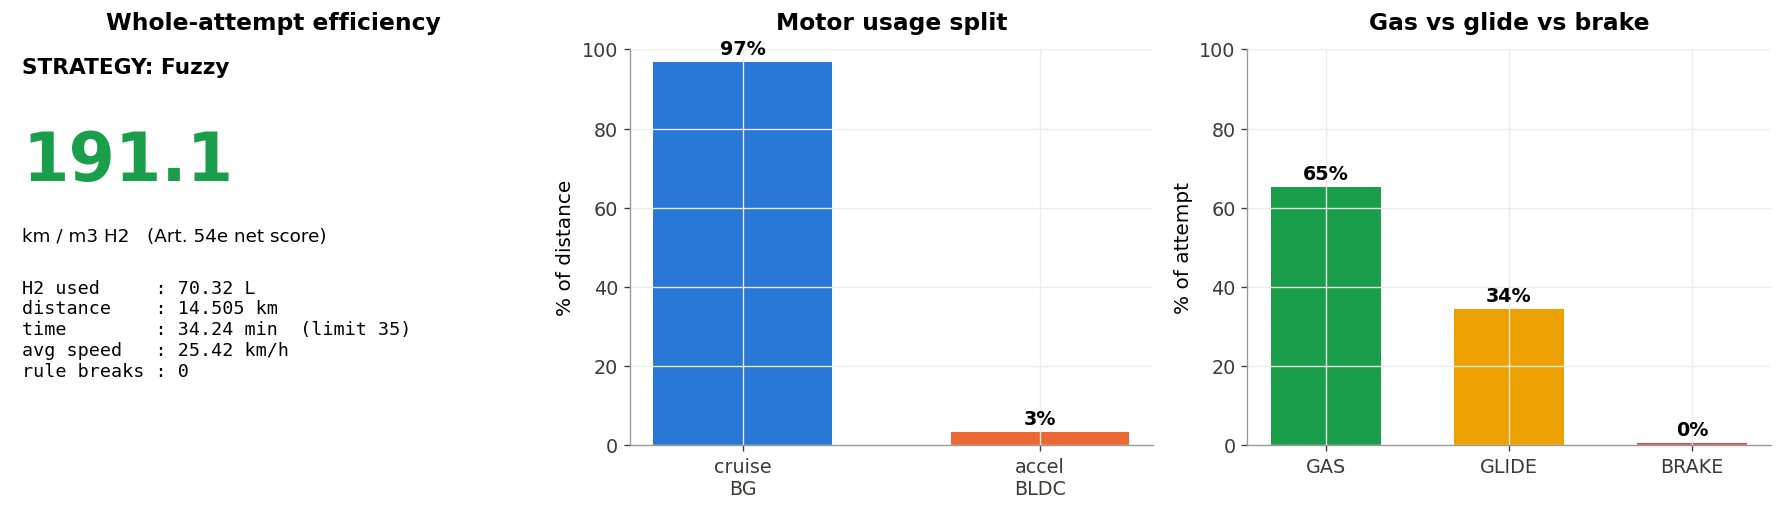

In [11]:
fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(15, 4.4))
# KPI card
ax0.axis('off')
kpi = ['STRATEGY: ' + TITLE, '', 'Art. 54e score', str(S['score_km_per_m3']) + '  km / m3 H2', '',
       'H2 used     : ' + str(S['h2_litres']) + ' L', 'distance    : ' + str(S['distance_km']) + ' km',
       'time        : ' + str(S['time_min']) + ' min  (limit 35)', 'avg speed   : ' + str(S['avg_speed_kmh']) + ' km/h',
       'rule breaks : ' + str(S['rule_violations'])]
ax0.text(0.02, 0.98, kpi[0], fontsize=13, fontweight='bold', va='top', transform=ax0.transAxes)
ax0.text(0.02, 0.80, S['score_km_per_m3'], fontsize=40, fontweight='bold', color='#1a9e4b', va='top', transform=ax0.transAxes)
ax0.text(0.02, 0.55, 'km / m3 H2   (Art. 54e net score)', fontsize=11, va='top', transform=ax0.transAxes)
ax0.text(0.02, 0.42, '\n'.join(kpi[5:]), fontsize=11, va='top', family='monospace', transform=ax0.transAxes)
ax0.set_title('Whole-attempt efficiency')
# motor share
sh = df.active_motor.value_counts(normalize=True) * 100
ax1.bar([('accel\n' if n == accel_motor.name else 'cruise\n') + n.split()[0] for n in sh.index],
        sh.values, color=[MOTOR_COLORS[n] for n in sh.index], width=0.6)
for i, v in enumerate(sh.values):
    ax1.text(i, v + 2, str(round(v)) + '%', ha='center', fontweight='bold')
ax1.set_ylim(0, 100); ax1.set_ylabel('% of distance'); ax1.set_title('Motor usage split')
# phase share
order = [p for p in ['gas', 'glide', 'brake'] if p in df.drive_phase.values]
pc = df.drive_phase.value_counts(normalize=True).reindex(order) * 100
ax2.bar([p.upper() for p in order], pc.values, color=[PHASE_COLORS[p] for p in order], width=0.6)
for i, v in enumerate(pc.values):
    ax2.text(i, v + 2, str(round(v)) + '%', ha='center', fontweight='bold')
ax2.set_ylim(0, 100); ax2.set_ylabel('% of attempt'); ax2.set_title('Gas vs glide vs brake')
plt.tight_layout(); plt.show()


## Hybrid fuel-cell + supercapacitor energy system  (SEM Art. 56c compliant)

The fuel cell runs in **parallel with a 3-series Maxwell BMOD0058 supercapacitor** feeding the
DC-DC converter. The FC is held at its **efficient operating point (558 W, 62%)** and the supercap
absorbs the launch peaks / returns energy during cruise; hydrogen is billed off the FC energy at
62% via Art. 54e's joulemeter formula. Per **SEM Art. 56c(iii)** the supercap voltage **after** the
run must be **>= before** it: the bank starts a little below full (headroom, so it can never
overcharge past V_max), and because the FC is idle most of the run it tops the cap back up to the
**start voltage** using that spare capacity -- so `V_end == V_start` at no extra run time. The lower
panel shows the supercap voltage returning exactly to its start line and never touching V_max.


Fuzzy hybrid energy system (SEM Art. 56c compliant):
  Supercap 3S : 19.3 F, 48 V max, 66 mOhm, 6.19 Wh
  FC op point : 558 W @ 62% efficiency   |   FC duty cycle: 42%
  SEM 56c(iii): Vstart 45.54 V  ->  Vend 45.54 V   (Vend >= Vstart: True)
                peak 47.72 V < Vmax 48 V (no overcharge)   |   post-run recharge: 14.0 s
  H2 (FC 62%) : 70.32 L   ->   Art.54e score 191.1 km/m3


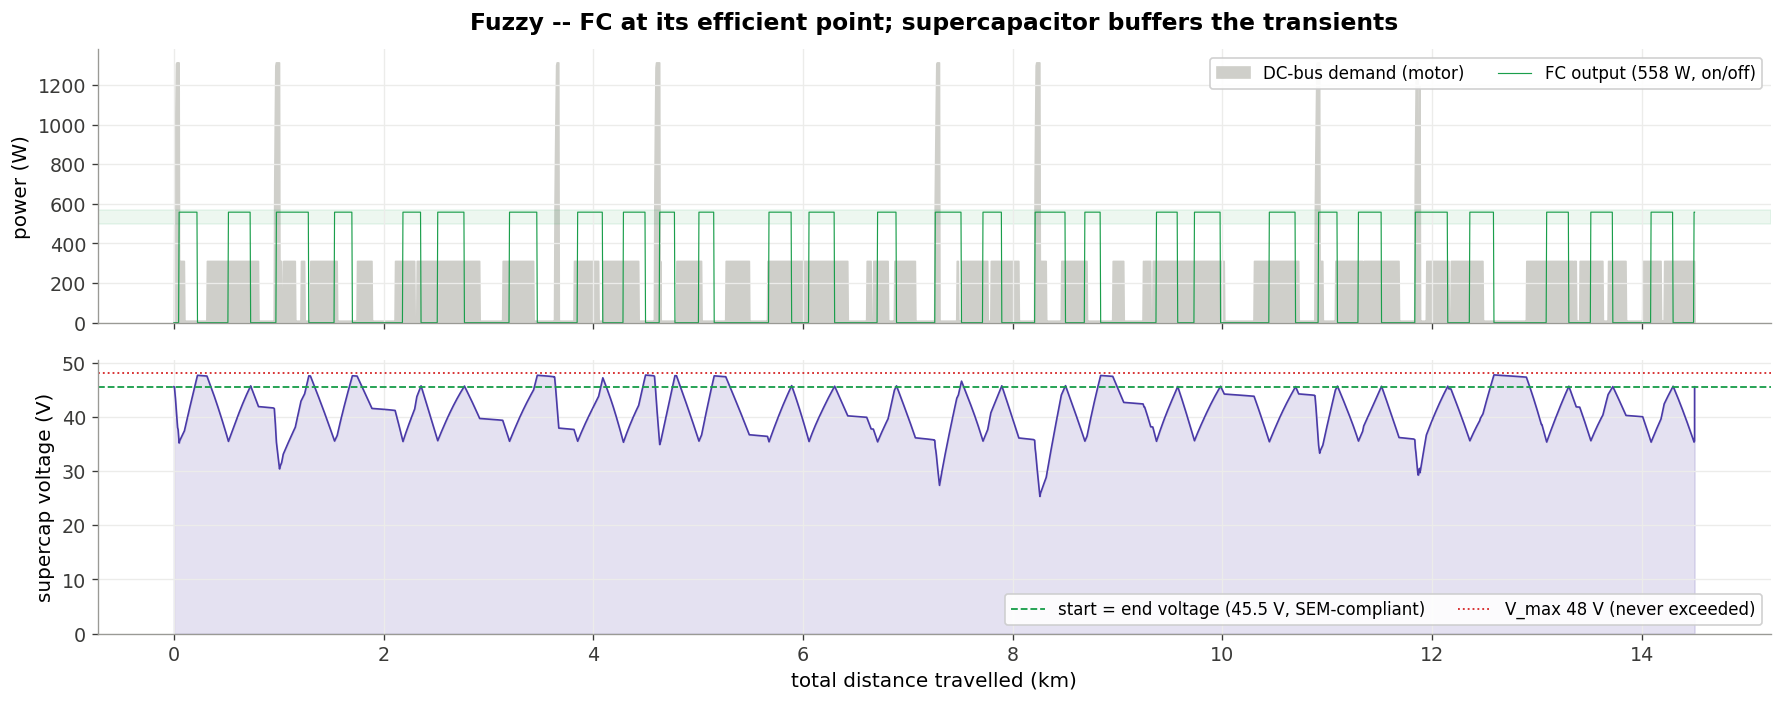

In [12]:
# ============ HYBRID FC + SUPERCAPACITOR ENERGY SYSTEM (SEM Art. 56c) =========
from digital_twin import hybrid_energy as _he
_D = df
_spec = _he.supercap_specs()
_duty = (_D.p_fc_out_w > 0).mean() * 100
_vmax = config.SUPERCAP_MODULE_V * config.SUPERCAP_N_SERIES
_vs, _ve = _D.supercap_v_start.iloc[0], _D.supercap_v_end.iloc[0]
print(f'{TITLE} hybrid energy system (SEM Art. 56c compliant):')
print(f'  Supercap 3S : {_spec["C"]:.1f} F, {_vmax:.0f} V max, {_spec["ESR"]*1000:.0f} mOhm, {_spec["E_max"]/3600:.2f} Wh')
print(f'  FC op point : {config.FC_HYBRID_OP_POWER_W:.0f} W @ {config.FC_HYBRID_EFF*100:.0f}% efficiency   |   FC duty cycle: {_duty:.0f}%')
print(f'  SEM 56c(iii): Vstart {_vs:.2f} V  ->  Vend {_ve:.2f} V   (Vend >= Vstart: {bool(_ve >= _vs - 1e-6)})')
print(f'                peak {_D.supercap_voltage_v.max():.2f} V < Vmax {_vmax:.0f} V (no overcharge)   |   post-run recharge: {_D.supercap_recharge_s.iloc[0]:.1f} s')
print(f'  H2 (FC 62%) : {S["h2_litres"]} L   ->   Art.54e score {S["score_km_per_m3"]} km/m3')

fig, (axA, axB) = plt.subplots(2, 1, figsize=(15, 6), sharex=True)
axA.fill_between(_D.distance_km, 0, _D.p_fc_elec_w, color='#cfcfca', label='DC-bus demand (motor)')
axA.plot(_D.distance_km, _D.p_fc_out_w, color='#1a9e4b', lw=0.7, label=f'FC output ({config.FC_HYBRID_OP_POWER_W:.0f} W, on/off)')
axA.axhspan(config.FC_HYBRID_BAND_W[0], config.FC_HYBRID_BAND_W[1], color='#1a9e4b', alpha=0.08)
axA.set_ylabel('power (W)'); axA.set_ylim(0, None); axA.legend(loc='upper right', ncol=2, framealpha=0.9)
axA.set_title(f'{TITLE} -- FC at its efficient point; supercapacitor buffers the transients')
axB.fill_between(_D.distance_km, 0, _D.supercap_voltage_v, color='#4a3aa7', alpha=0.15)
axB.plot(_D.distance_km, _D.supercap_voltage_v, color='#4a3aa7', lw=1.0)
axB.axhline(_vs, color='#1a9e4b', ls='--', lw=1.1, label=f'start = end voltage ({_vs:.1f} V, SEM-compliant)')
axB.axhline(_vmax, color='#d62728', ls=':', lw=1.1, label=f'V_max {_vmax:.0f} V (never exceeded)')
axB.set_ylabel('supercap voltage (V)'); axB.set_xlabel('total distance travelled (km)')
axB.set_ylim(0, _vmax * 1.05); axB.legend(loc='lower right', framealpha=0.9, ncol=2)
plt.tight_layout(); plt.show()


## Takeaway
This is the **raw Fuzzy run as a real driver would execute it** -- the optimal plan degraded by bounded human
errors and the two-motor servo switch. Efficiency is naturally a little lower and hydrogen a little higher than the
perfect plan, the four laps still finish inside the 35-minute limit, and the compulsory stop-&-gos remain valid.
The driver heatmap and strategy-zone chart show *where the car actually gassed, glided and switched motors* during
the imperfect run; the Art. 54e score (km per m3 of H2) above is the realistic efficiency of this execution.
